In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter("ignore")

In [2]:
df_train = pd.read_csv("/kaggle/input/playground-series-s5e5/train.csv")
df_test = pd.read_csv("/kaggle/input/playground-series-s5e5/test.csv")

In [3]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          750000 non-null  int64  
 1   Sex         750000 non-null  object 
 2   Age         750000 non-null  int64  
 3   Height      750000 non-null  float64
 4   Weight      750000 non-null  float64
 5   Duration    750000 non-null  float64
 6   Heart_Rate  750000 non-null  float64
 7   Body_Temp   750000 non-null  float64
 8   Calories    750000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 51.5+ MB


In [4]:
df_train.head()

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,female,38,166.0,61.0,25.0,102.0,40.6,146.0


In [5]:
df_test.head()

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,750000,male,45,177.0,81.0,7.0,87.0,39.8
1,750001,male,26,200.0,97.0,20.0,101.0,40.5
2,750002,female,29,188.0,85.0,16.0,102.0,40.4
3,750003,female,39,172.0,73.0,20.0,107.0,40.6
4,750004,female,30,173.0,67.0,16.0,94.0,40.5


In [6]:
# missing values
print("Train Set Missing Values")
print(df_train.isna().sum())
print( )
print("Test Set Missing Values")
print(df_test.isna().sum())

Train Set Missing Values
id            0
Sex           0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

Test Set Missing Values
id            0
Sex           0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
dtype: int64


wowow no missing values!

In [7]:
# summary statistics
print("Train Set Summary Statistics")
print(df_train.describe())
print( )
print("Test Set Summary Statistics")
print(df_test.describe())

Train Set Summary Statistics
                  id            Age         Height         Weight  \
count  750000.000000  750000.000000  750000.000000  750000.000000   
mean   374999.500000      41.420404     174.697685      75.145668   
std    216506.495284      15.175049      12.824496      13.982704   
min         0.000000      20.000000     126.000000      36.000000   
25%    187499.750000      28.000000     164.000000      63.000000   
50%    374999.500000      40.000000     174.000000      74.000000   
75%    562499.250000      52.000000     185.000000      87.000000   
max    749999.000000      79.000000     222.000000     132.000000   

            Duration     Heart_Rate      Body_Temp       Calories  
count  750000.000000  750000.000000  750000.000000  750000.000000  
mean       15.421015      95.483995      40.036253      88.282781  
std         8.354095       9.449845       0.779875      62.395349  
min         1.000000      67.000000      37.100000       1.000000  
25%      

The summary statistics for both datasets look roughly similar, no need to account for differences in samples

In [8]:
len(df_train)

750000

In [9]:
df_all = pd.concat([df_train, df_test]).reset_index(drop=True)

train_indices = len(df_train) - 1

df_all.describe()

,id,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,750000.000000
mean,499999.500000,41.428419,174.704670,75.146179,15.419618,95.482767,40.036213,88.282781
std,288675.278933,15.175728,12.823881,13.981899,8.352851,9.449920,0.779518,62.395349
min,0.000000,20.000000,126.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,249999.750000,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,34.000000
50%,499999.500000,40.000000,174.000000,74.000000,15.000000,95.000000,40.300000,77.000000
75%,749999.250000,52.000000,185.000000,87.000000,23.000000,103.000000,40.700000,136.000000
max,999999.000000,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


# EDA

## Numeric Features

In [10]:
df_train.drop(columns=['id'], inplace=True)
num_vars = df_train.select_dtypes(include=['int64','float64']).columns
cat_vars = ['Sex']

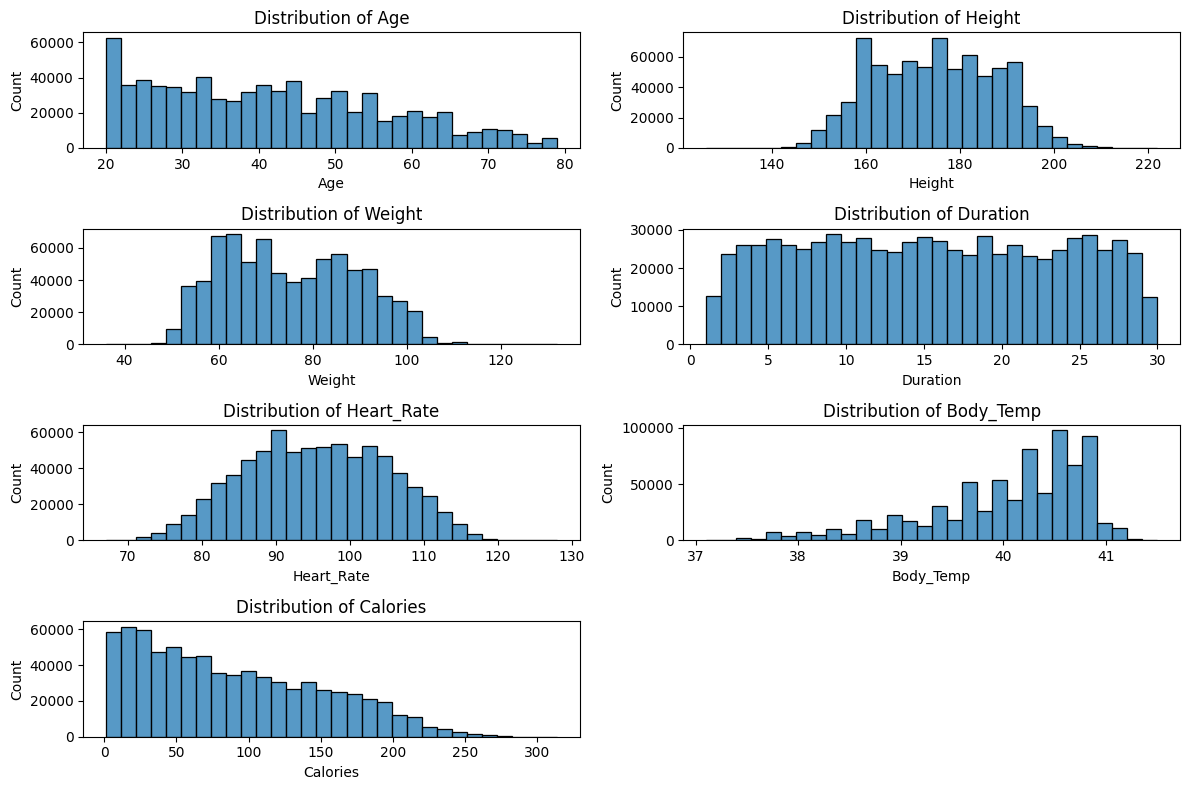

In [11]:
# distribution of Numeric Features
fig, axes = plt.subplots(4, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(num_vars):
    sns.histplot(df_train[feature], ax=axes[i], bins=min(30, df_train[feature].nunique()))
    axes[i].set_title(f"Distribution of {feature}")

axes[7].remove()
plt.tight_layout()
plt.show()

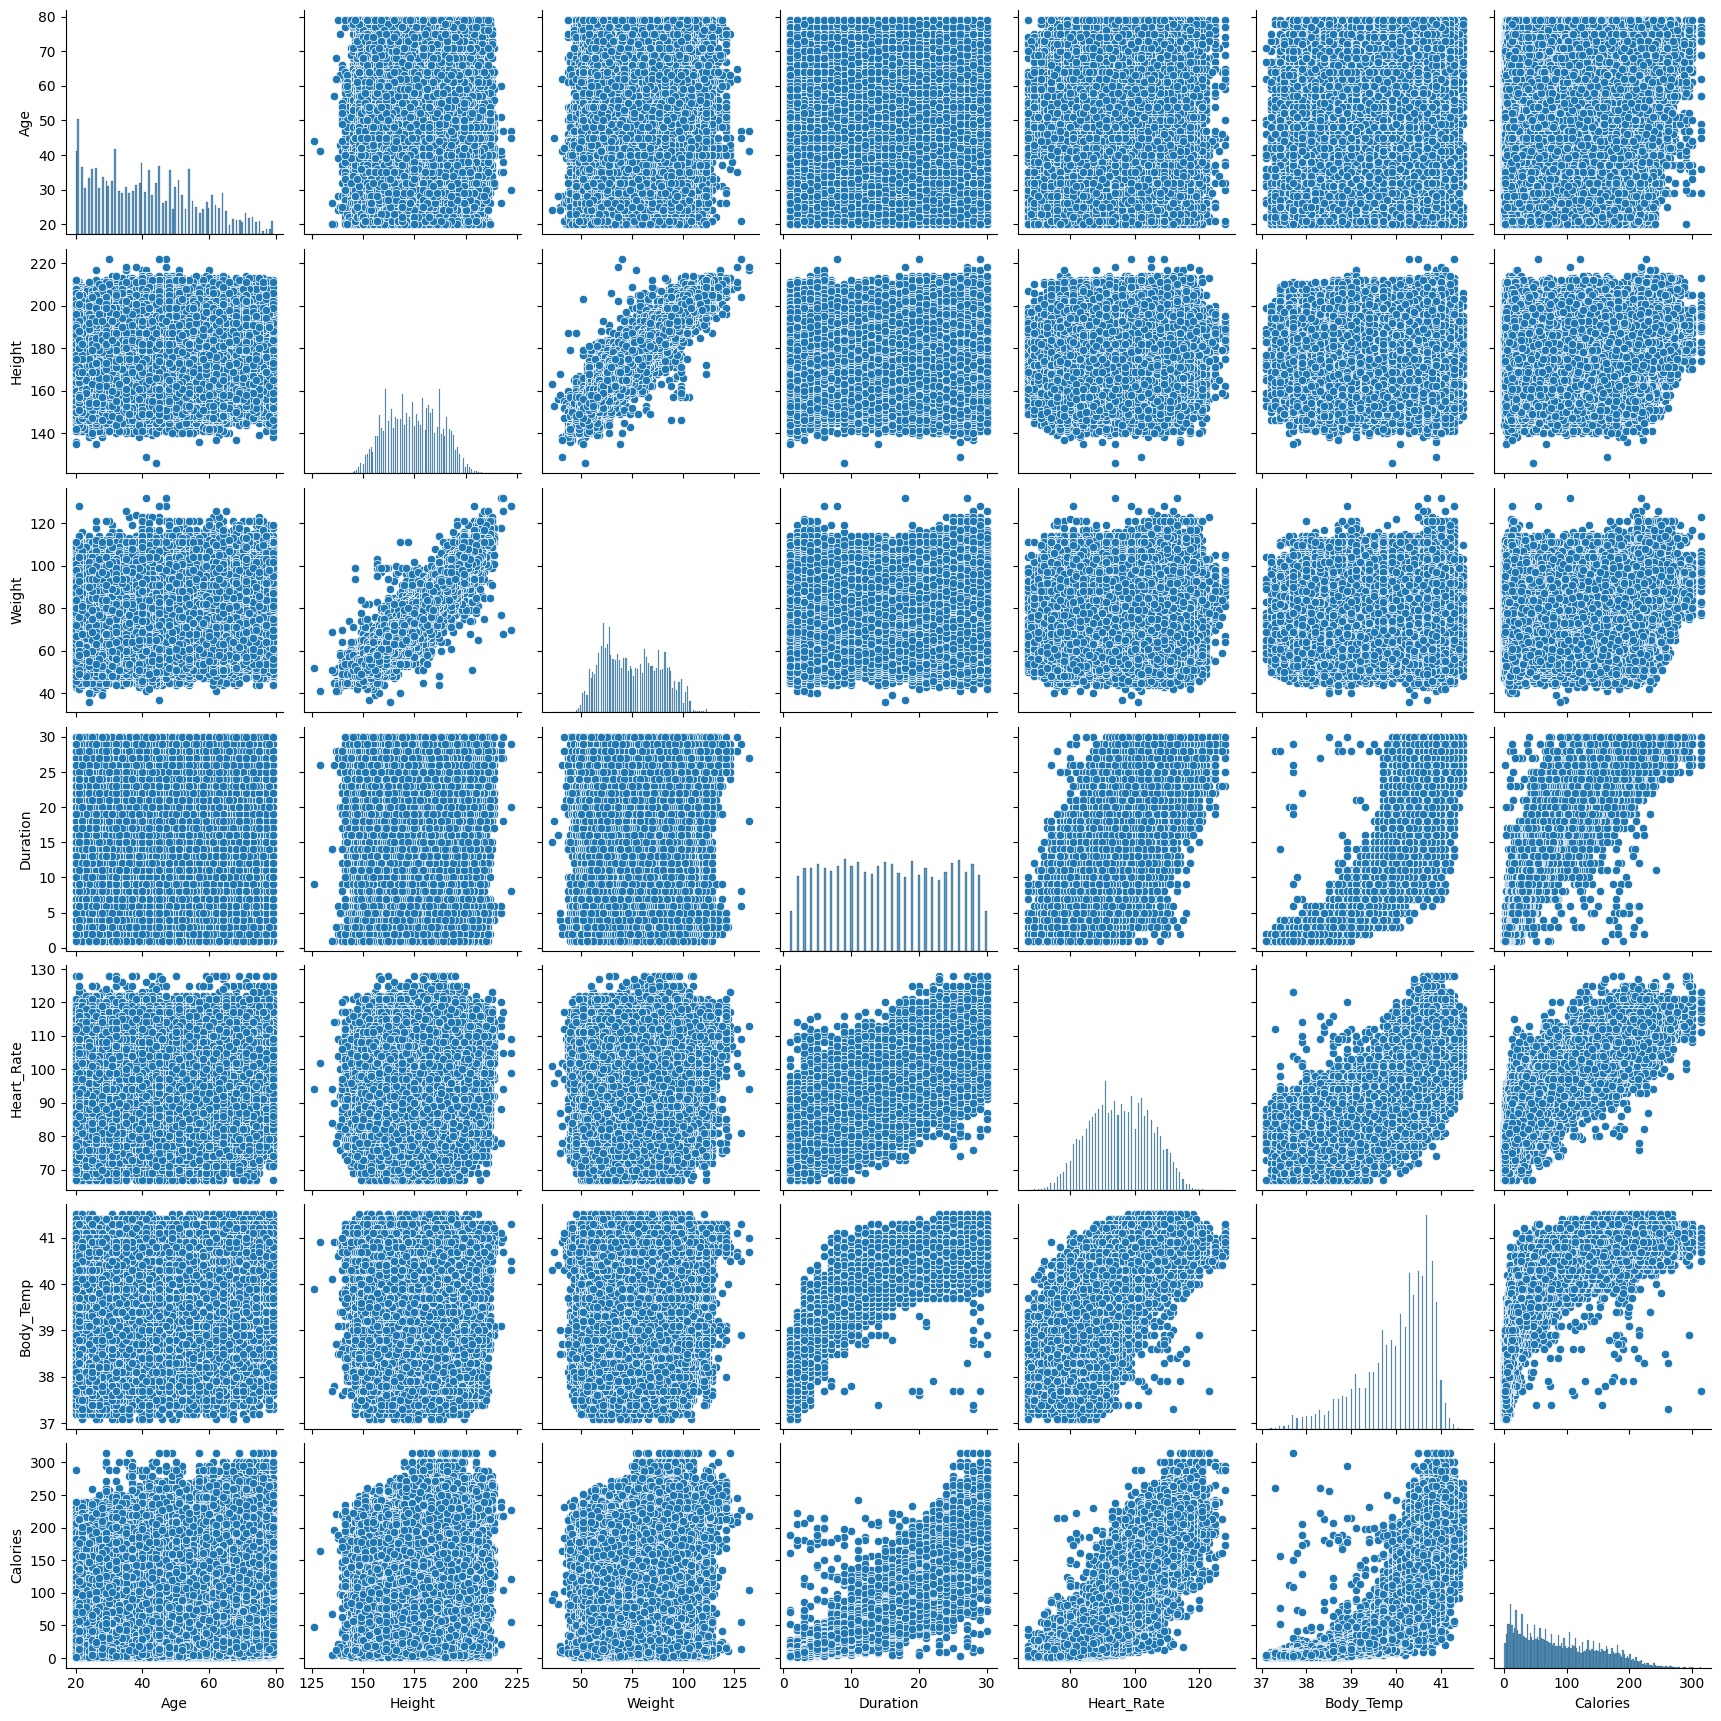

In [12]:
# Scatterplots between features
sns.pairplot(df_train[num_vars])
plt.show()

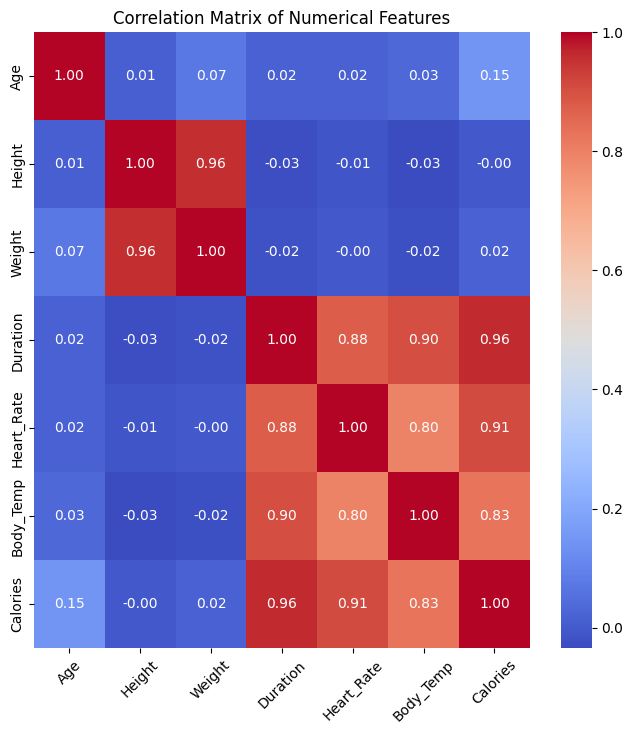

In [13]:
# correlation Matrix
corr_matrix = df_train[num_vars].corr()
plt.figure(figsize=(8, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.xticks(rotation=45)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

### Findings from Analysis of Numerical Features
#### Relationships and Nature of Variables
- There are quite a few significantly correlated features. However, most of the relationship occurs in a non-linear manner as seen in the scatterplot. To account for this, log transformations and exponential transformations will be applied.
- The outcome variable calories is highly right skewed, it might be worth applying a log transformation to make it normally distributed. This should also help with making the relationships between many of the variables and the outcome to be linear.
#### Things to Try
- Applying log transformations to calories
- Looking into interaction terms for investigating how variables such as age, height, and weight, may be indirectly correlated with the outcome variable calories

## Categorical Feature

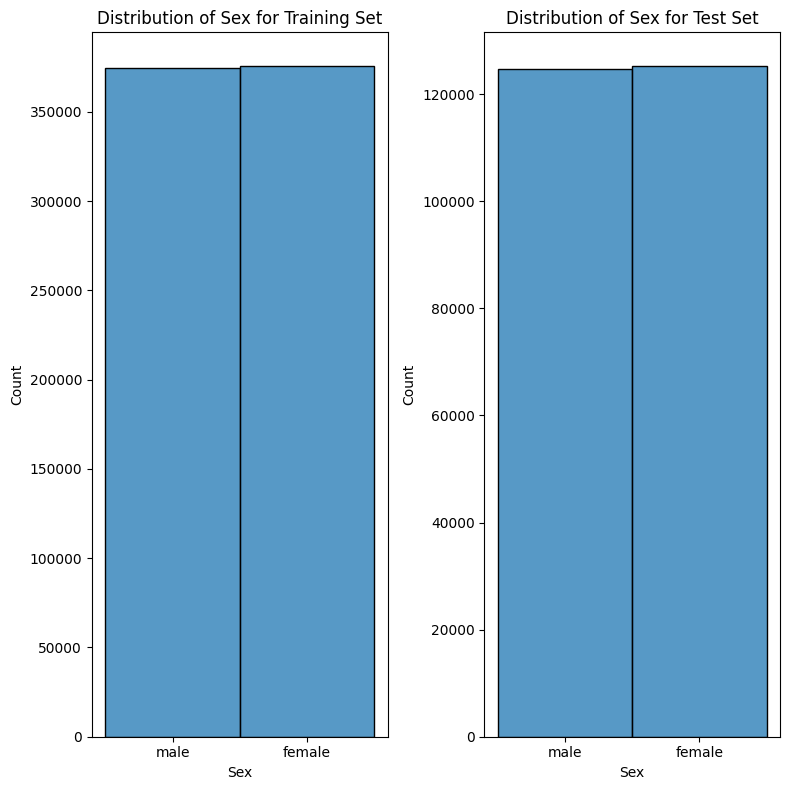

In [14]:
# distribution of sex
fig, axes = plt.subplots(1, 2, figsize=(8, 8))
axes = axes.flatten()

sns.histplot(df_train['Sex'], ax=axes[0])
axes[0].set_title("Distribution of Sex for Training Set")
sns.histplot(df_test['Sex'], ax=axes[1])
axes[1].set_title("Distribution of Sex for Test Set")

plt.tight_layout()
plt.show()

- There is a even amount of males and females in the sample, not much to worry about here

## Numeric and Categorical Features

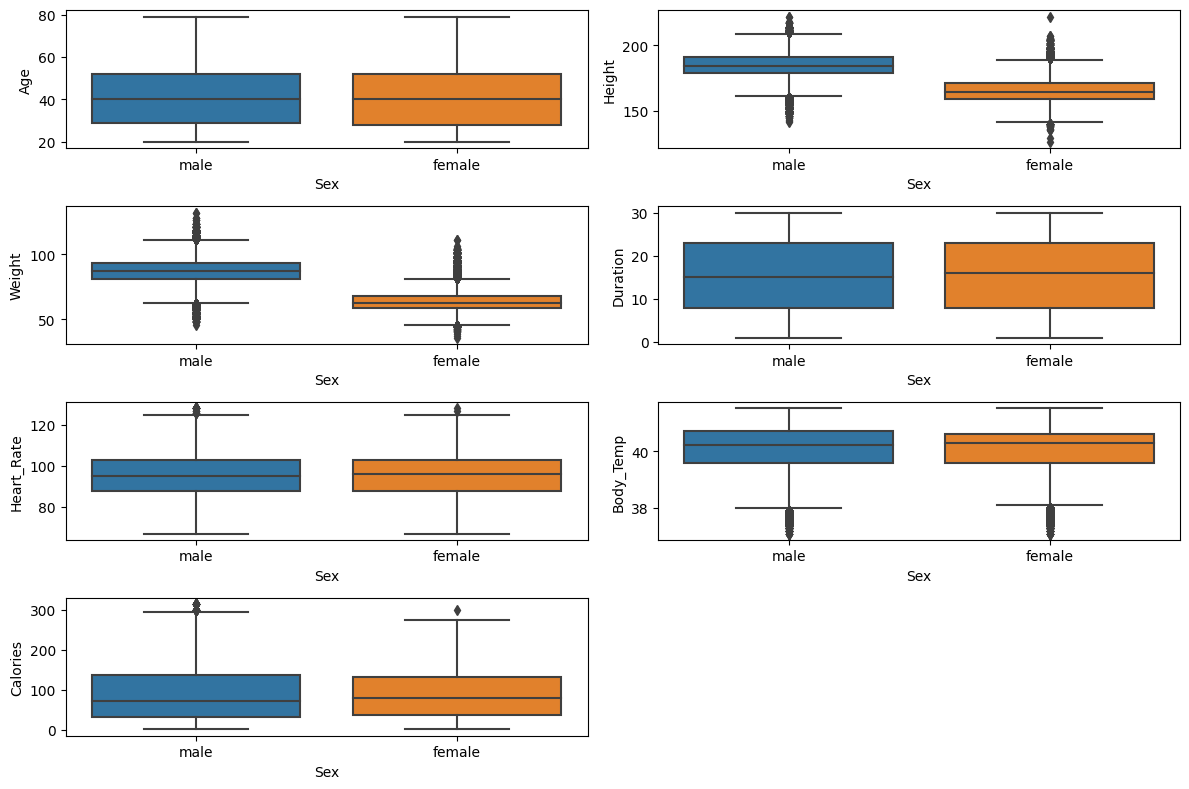

In [15]:
fig, axes = plt.subplots(4, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(num_vars):
    sns.boxplot(x=df_train['Sex'], y=df_train[feature], ax=axes[i])
    plt.title(f"Relationship Between {feature} and Sex")

axes[7].remove()
plt.tight_layout()
plt.show()

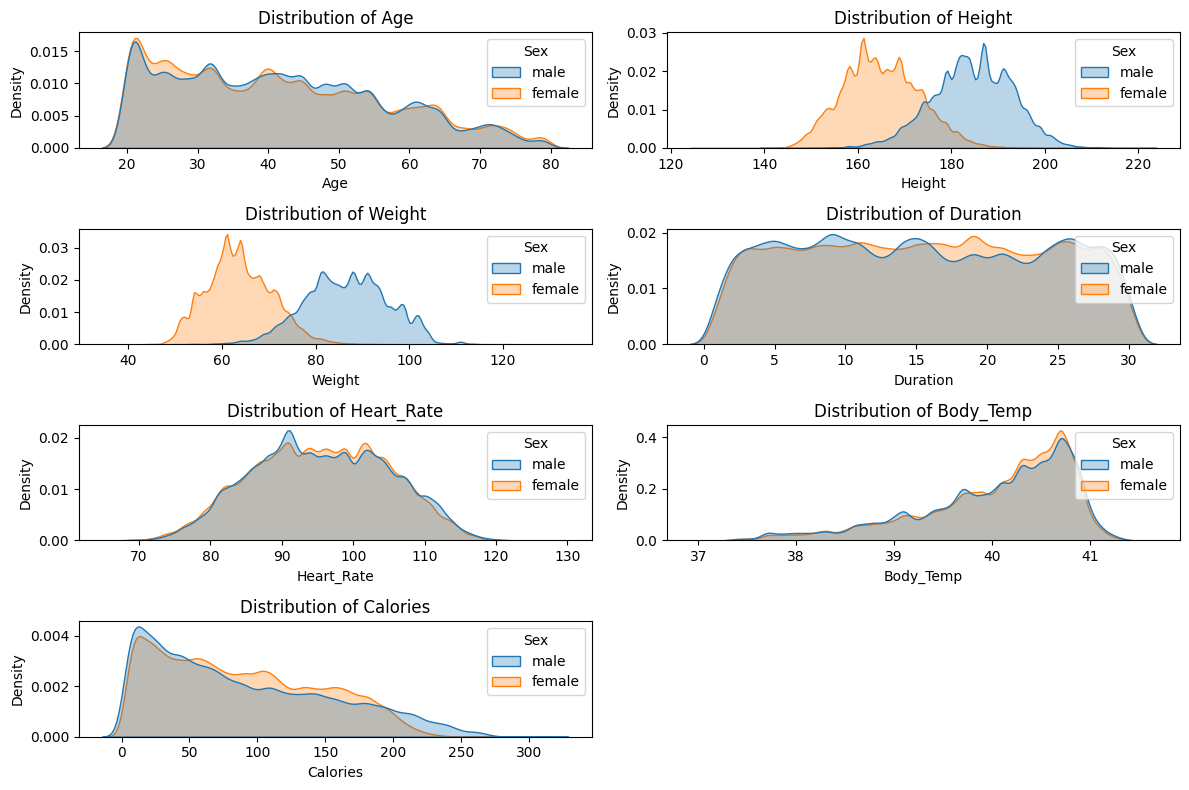

In [16]:
# distribution of Numeric Features filtered by gender
fig, axes = plt.subplots(4, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(num_vars):
    sns.kdeplot(data=df_train, x=feature, ax=axes[i], hue='Sex', fill=True, alpha=0.3)
    axes[i].set_title(f"Distribution of {feature}")

axes[7].remove()
plt.tight_layout()
plt.show()

### Findings from Analysis of Numerical and Cateogircal Features
- For the majority of the features, they do not differ in distribution between genders except for weight and height
- There also appears to be slightly more skew in calories for males compared to females (idk how to interpret this but I'm sure it's useful for something)
- There does not appear to be a significant difference in the mean calories burn for males and females but it is possible that there might be some indirect relationship through the variables of weight and height

# Adding in Bonus Features!

In [17]:
from sklearn.preprocessing import StandardScaler

def make_features(df, test=False):
    df_temp = df.copy()

    # dummy encoding
    df_temp = pd.get_dummies(df_temp, columns=['Sex'])

    # log and exponential features
    df_temp['log_heart_rate'] = np.log(df_temp['Heart_Rate'])
    df_temp['log_duration'] = np.log(df_temp['Duration'])
    df_temp['exp_body_temp'] = np.exp(df_temp['Body_Temp']) # exponential relationship

    # new features, to be culled off in feature selection
    df_temp['BMI'] = df_temp['Weight'] / (df_temp['Height']/100)**2

    # transformations of outcome variable
    if test == False:
        df_temp['log_calories'] = np.log(df_temp['Calories'])
    
    return df_temp

In [18]:
df_train1 = make_features(df_train)

In [19]:
# domain_specific_features = ['BMI', 'Duration_Heart_Rate', ]
num_features = df_train1.select_dtypes(include=['int64','float64']).columns
feat_with_log = ['BMI', 'log_duration', 'log_heart_rate', 'exp_body_temp', 'Calories', 'log_calories']
feat_no_log = ['BMI', 'Duration', 'Heart_Rate', 'Body_Temp', 'Calories', 'log_calories']

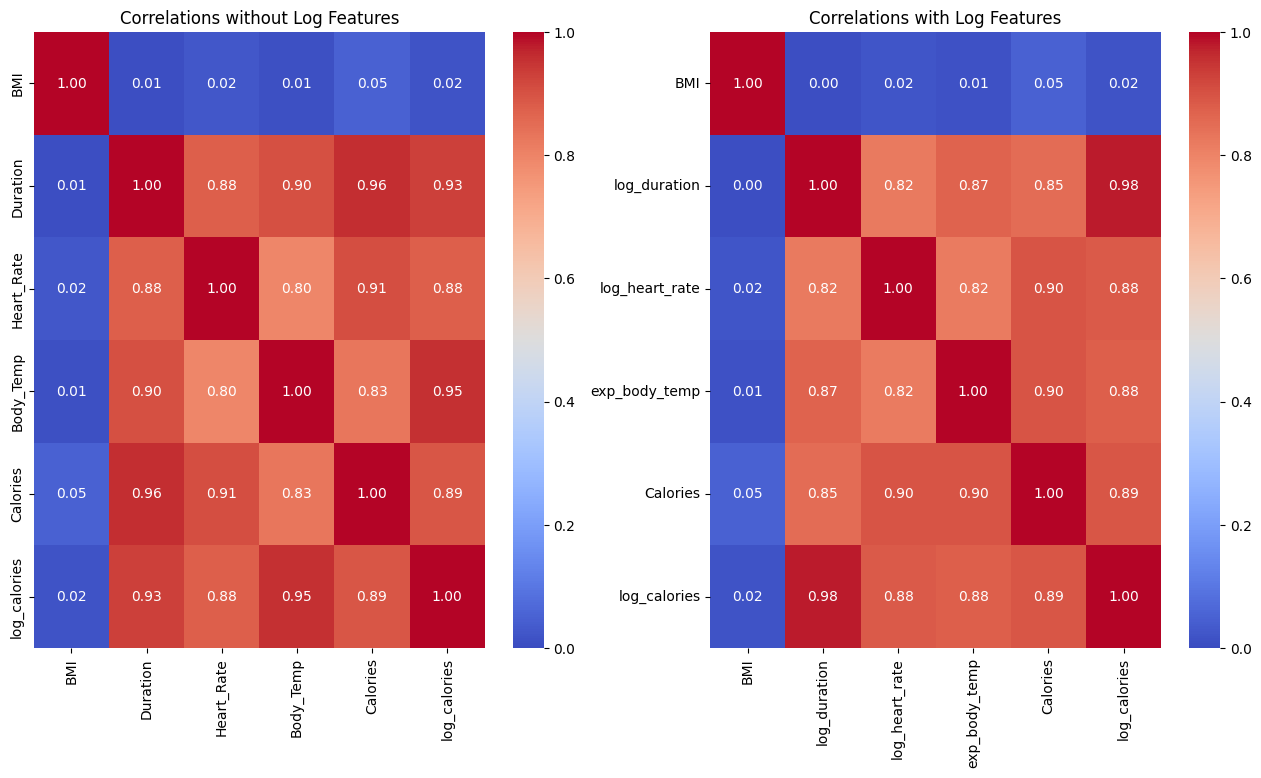

In [20]:
corr_matrix_no_log = df_train1[feat_no_log].corr()
corr_matrix_log = df_train1[feat_with_log].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes = axes.flatten()

sns.heatmap(corr_matrix_no_log, annot=True, fmt='.2f', cmap='coolwarm', vmin=0, vmax=1, ax=axes[0])
sns.heatmap(corr_matrix_log, annot=True, fmt='.2f', cmap='coolwarm', vmin=0, vmax=1, ax=axes[1])
axes[0].set_title("Correlations without Log Features")
axes[1].set_title("Correlations with Log Features")

plt.show()

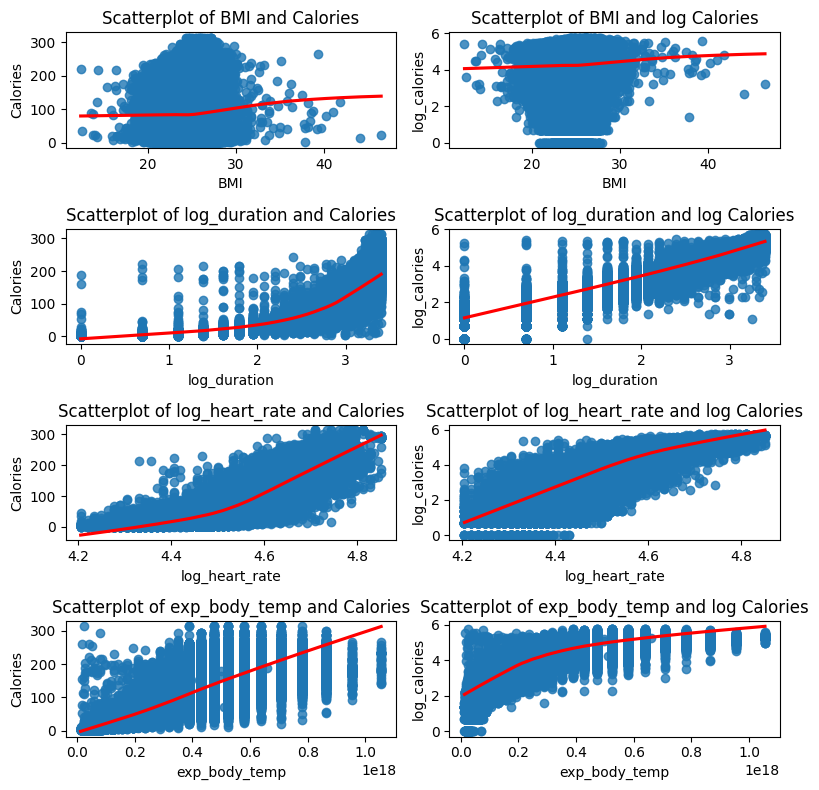

In [21]:
# scatterplots for relationship between log and exponential features and outcome
feat_with_log = ['BMI', 'log_duration', 'log_heart_rate', 'exp_body_temp']

fig, axes = plt.subplots(4, 2, figsize=(8, 8))

for i in range(len(feat_with_log)):
    # sns.scatterplot(data=df_train1, x=feat_with_log[i], y='Calories', ax=axes[i][0])
    sns.regplot(data=df_train1, x=feat_with_log[i], y='Calories', ax=axes[i][0], lowess=True, line_kws={"color":"red"})
    axes[i][0].set_title(f'Scatterplot of {feat_with_log[i]} and Calories')
    # sns.scatterplot(data=df_train1, x=feat_with_log[i], y='log_calories', ax=axes[i][1])
    sns.regplot(data=df_train1, x=feat_with_log[i], y='log_calories', ax=axes[i][1], lowess=True, line_kws={"color":"red"})
    axes[i][1].set_title(f'Scatterplot of {feat_with_log[i]} and log Calories')

plt.tight_layout()
plt.show()

### Findings for Relations With Log Features
* For a couple of the features, the correlation with the outcome variable greatly increases when accounting exponential and logorithmic transformations.
* When looking at scatterplots for exp body temp and Calories, there appears to be large variance near the middle of the predictor variable.
* Relationship between log calories and log duration is wild

# Interaction Terms

In [22]:
df_train1.head()

,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories,Sex_female,Sex_male,log_heart_rate,log_duration,exp_body_temp,BMI,log_calories
0,36,189.0,82.0,26.0,101.0,41.0,150.0,False,True,4.615121,3.258097,6.398435e+17,22.955684,5.010635
1,64,163.0,60.0,8.0,85.0,39.7,34.0,True,False,4.442651,2.079442,1.743777e+17,22.582709,3.526361
2,51,161.0,64.0,7.0,84.0,39.8,29.0,True,False,4.430817,1.945910,1.927172e+17,24.690405,3.367296
3,20,192.0,90.0,25.0,105.0,40.7,140.0,False,True,4.653960,3.218876,4.740077e+17,24.414062,4.941642
4,38,166.0,61.0,25.0,102.0,40.6,146.0,True,False,4.624973,3.218876,4.288999e+17,22.136740,4.983607


In [23]:
def make_interactions(df, test = False, log = False):
    df_temp = df.copy()

    num_features = df_temp.drop(columns=['Calories']).select_dtypes(include=['int64', 'float64']).columns
    if log == True:
        num_features = df_temp.drop(columns=['Calories', 'log_calories']).select_dtypes(include=['int64', 'float64']).columns
    
    cat_features = ['Sex_female', 'Sex_male']

    num_only_int = []
    cat_num_int = []
    # numeric and numeric interactions
    for i in range(len(num_features)):
        for j in range(i+1, len(num_features)):
            df_temp[f"{num_features[i]}_{num_features[j]}"] = df_temp[num_features[i]] * df_temp[num_features[j]]
            num_only_int.append(f"{num_features[i]}_{num_features[j]}")

    # sex female and all numeric features
    for sex in cat_features:
        for i in range(len(num_features)):
            df_temp[f"{sex}_{num_features[i]}"] = df_temp[sex] * df_temp[num_features[i]]
            cat_num_int.append(f"{sex}_{num_features[i]}")

    return df_temp, num_only_int, cat_num_int

In [24]:
df_train2 = pd.get_dummies(df_train, columns=['Sex'])
df_train2, num_only_int, cat_num_int = make_interactions(df_train2)
df_train2.head()

,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories,Sex_female,Sex_male,Age_Height,...,Sex_female_Weight,Sex_female_Duration,Sex_female_Heart_Rate,Sex_female_Body_Temp,Sex_male_Age,Sex_male_Height,Sex_male_Weight,Sex_male_Duration,Sex_male_Heart_Rate,Sex_male_Body_Temp
0,36,189.0,82.0,26.0,101.0,41.0,150.0,False,True,6804.0,...,0.0,0.0,0.0,0.0,36,189.0,82.0,26.0,101.0,41.0
1,64,163.0,60.0,8.0,85.0,39.7,34.0,True,False,10432.0,...,60.0,8.0,85.0,39.7,0,0.0,0.0,0.0,0.0,0.0
2,51,161.0,64.0,7.0,84.0,39.8,29.0,True,False,8211.0,...,64.0,7.0,84.0,39.8,0,0.0,0.0,0.0,0.0,0.0
3,20,192.0,90.0,25.0,105.0,40.7,140.0,False,True,3840.0,...,0.0,0.0,0.0,0.0,20,192.0,90.0,25.0,105.0,40.7
4,38,166.0,61.0,25.0,102.0,40.6,146.0,True,False,6308.0,...,61.0,25.0,102.0,40.6,0,0.0,0.0,0.0,0.0,0.0


In [25]:
df_train2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 36 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Age                    750000 non-null  int64  
 1   Height                 750000 non-null  float64
 2   Weight                 750000 non-null  float64
 3   Duration               750000 non-null  float64
 4   Heart_Rate             750000 non-null  float64
 5   Body_Temp              750000 non-null  float64
 6   Calories               750000 non-null  float64
 7   Sex_female             750000 non-null  bool   
 8   Sex_male               750000 non-null  bool   
 9   Age_Height             750000 non-null  float64
 10  Age_Weight             750000 non-null  float64
 11  Age_Duration           750000 non-null  float64
 12  Age_Heart_Rate         750000 non-null  float64
 13  Age_Body_Temp          750000 non-null  float64
 14  Height_Weight          750000 non-nu

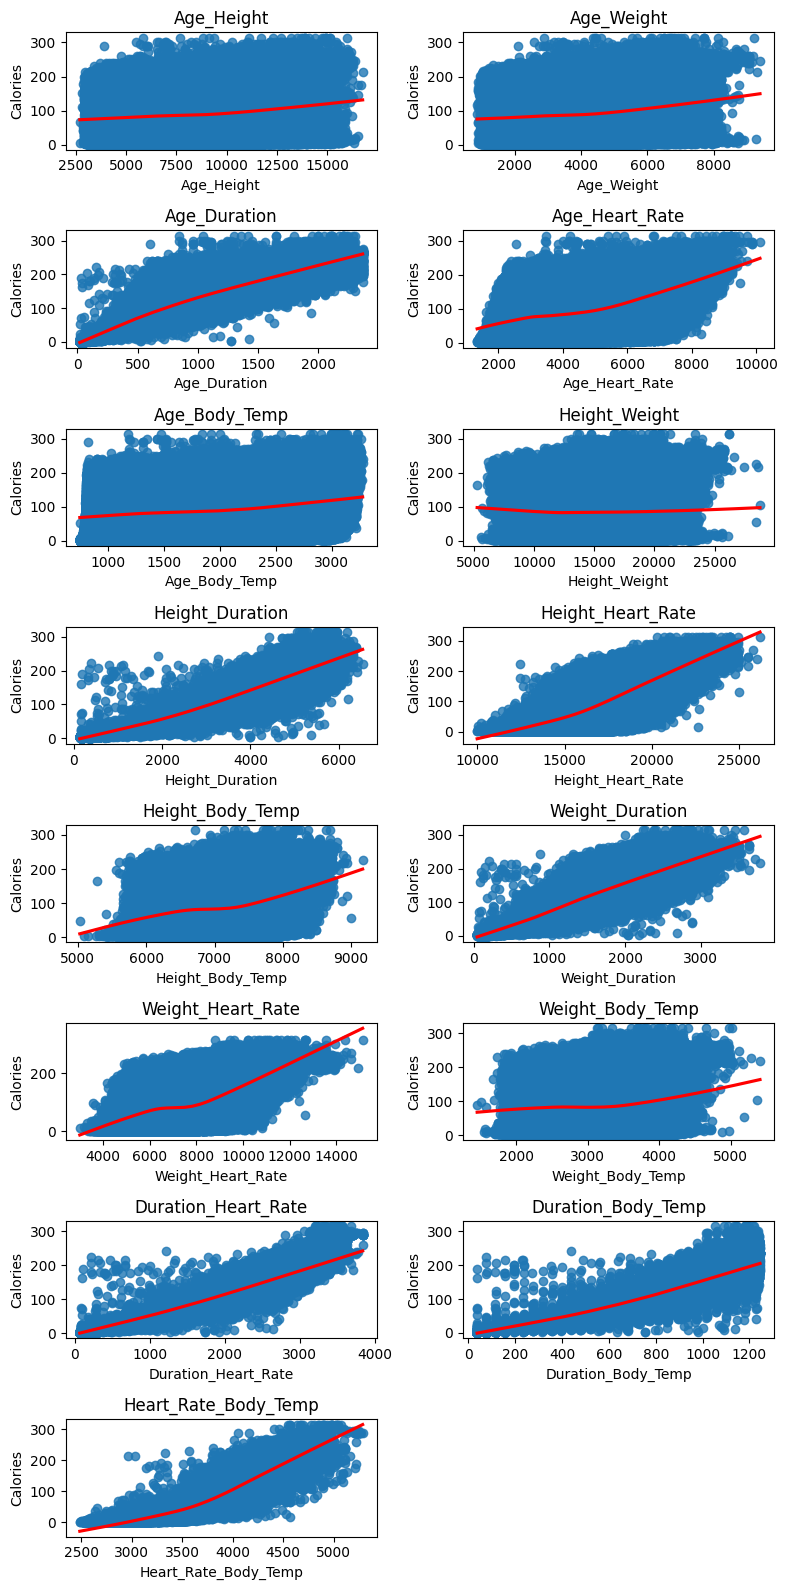

In [26]:
fig, axes = plt.subplots(8, 2, figsize=(8, 16))
axes = axes.flatten()

for i, feature in enumerate(num_only_int):
    # sns.scatterplot(data=df_train2, x=feature, y='Calories', ax=axes[i])
    sns.regplot(data=df_train2, x=feature, y='Calories', lowess=True, ax=axes[i], line_kws={"color": "red"})
    axes[i].set_title(f"{feature}")

axes[15].remove()
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Correlations for Num Num Interactions')

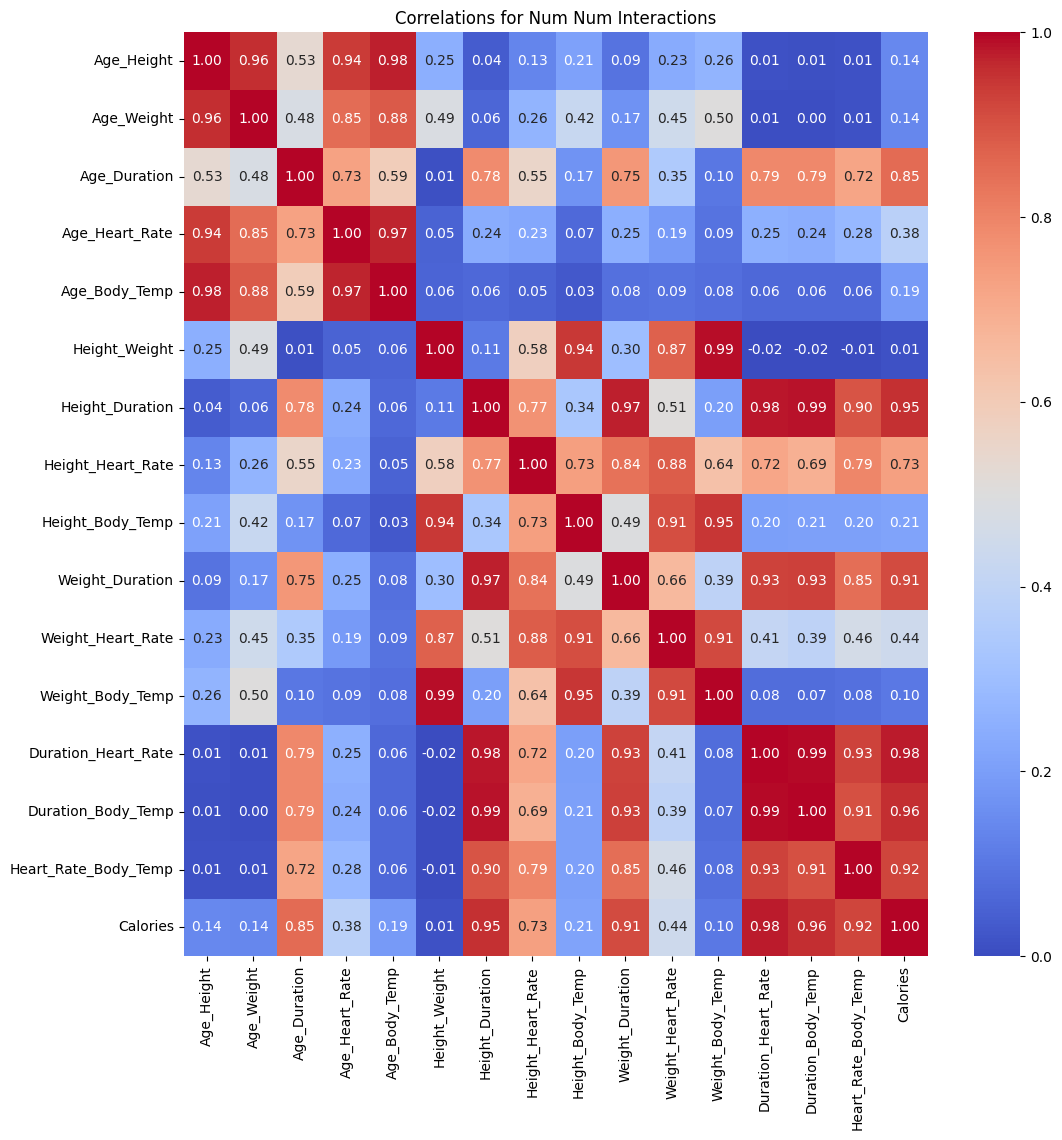

In [27]:
# correlation matrix for num only int
num_only_int2 = num_only_int + ['Calories']
corr_matrix = df_train2[num_only_int2].corr()
plt.figure(figsize=(12, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=0, vmax=1)
plt.title("Correlations for Num Num Interactions")

# What if I just shove everything into a XGB Model
That would be funny

In [28]:
df_train2 = make_features(df_train)
df_train2, _, _ = make_interactions(df_train2)

In [29]:
col_to_drop = [col for col in df_train2.columns if 'alories' in col]

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
X = df_train2.drop(columns=col_to_drop)
y = df_train2['Calories']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3)

In [32]:
import xgboost as xgb
from sklearn.metrics import mean_squared_log_error

In [33]:
model = xgb.XGBRegressor()
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [34]:
y_val_pred = model.predict(X_val)
score = np.sqrt(mean_squared_log_error(y_val_pred, y_val))
print(f"Validation score: {score}")

Validation score: 0.06400310446851758
